In [5]:
from warnings import filterwarnings
filterwarnings('ignore')

In [6]:
path = r"c:\Users\Rahul Bamane\Downloads\classification-train-dataset.csv"
import pandas as pd
df = pd.read_csv(path)
df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [7]:
df.shape

(136429, 14)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  str    
 2   Type                     136429 non-null  str    
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-null  int64  
 9   TWF                      136429 non-null  int64  
 10  HDF                      136429 non-null  int64  
 11  PWF                      136429 non-null  int64  
 12  OSF                      136429 non-null  int64  
 13  RNF                      136429 non-null  int64  
dtypes: float64(3), 

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates

<bound method DataFrame.drop_duplicates of             id Product ID Type  Air temperature [K]  Process temperature [K]  \
0            0     L50096    L                300.6                    309.6   
1            1     M20343    M                302.6                    312.1   
2            2     L49454    L                299.3                    308.5   
3            3     L53355    L                301.0                    310.9   
4            4     M24050    M                298.0                    309.0   
...        ...        ...  ...                  ...                      ...   
136424  136424     M22284    M                300.1                    311.4   
136425  136425     H38017    H                297.5                    308.5   
136426  136426     L54690    L                300.5                    311.8   
136427  136427     L53876    L                301.7                    310.9   
136428  136428     L47937    L                296.9                    308.1 

In [11]:
df.isna().sum()

id                         0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Observe if the data is balanced or imbalanced

In [12]:
df['Machine failure'].unique()

array([0, 1])

In [13]:
df['Machine failure'].value_counts()

Machine failure
0    134281
1      2148
Name: count, dtype: int64

Data is imbalanced.

In [14]:
df.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

 Exploratory Data Analysis (EDA)

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

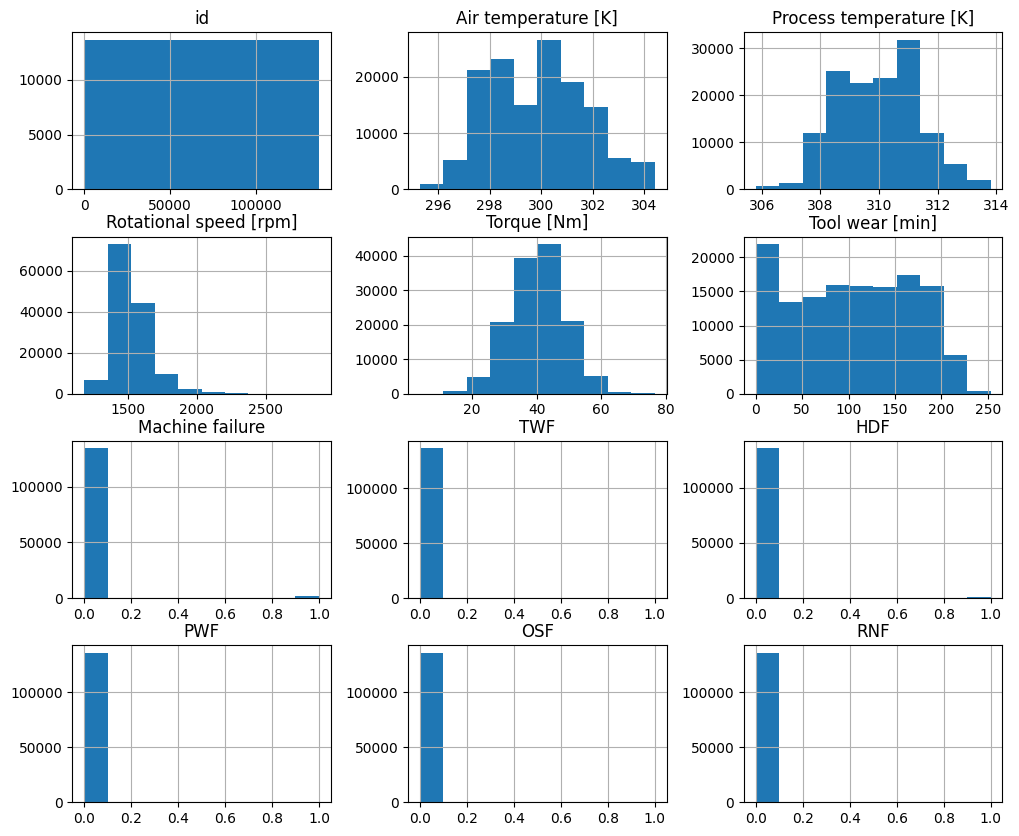

In [16]:
df.hist(figsize=(12,10))
plt.show()

Correlation Heatmap

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

ValueError: could not convert string to float: 'L50096'

<Figure size 1000x800 with 0 Axes>

Compare Failed vs Non-Failed

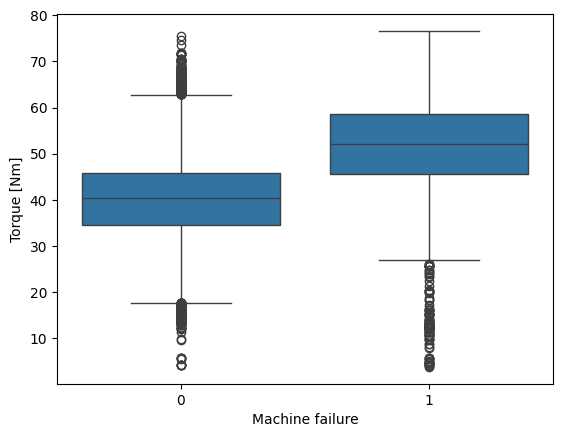

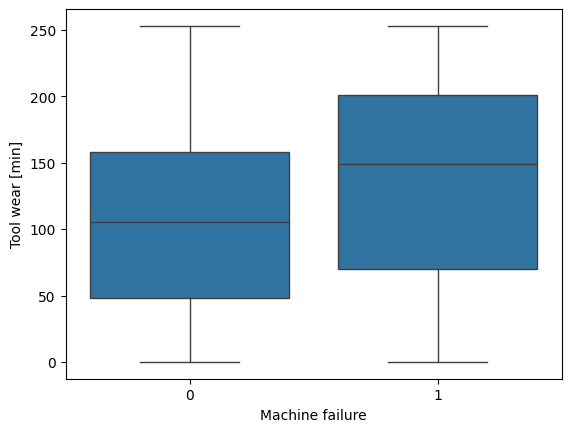

In [21]:
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df)
plt.show()

sns.boxplot(x='Machine failure', y='Tool wear [min]', data=df)
plt.show()

Obervations:

Higher torque → more failures

Higher tool wear → higher probability of failure

Temperature difference matters

Data Cleaning and Data Preprocessing

In [22]:
df["Temp Difference"] = df["Process temperature [K]"] - df["Air temperature [K]"]

Ensure correct datatypes:

In [23]:
df["Type"] = df["Type"].astype("category")

In [24]:
X=df.drop(columns=['id', 'Product ID','Machine failure'])
Y=df[['Machine failure']]

In [27]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

cat = list(X.select_dtypes(include='str').columns)
con = list(X.select_dtypes(include='number').columns)

num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

cat_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore',sparse_output=False)
)

pre = ColumnTransformer([
    ('cat',cat_pipe,cat),
    ('con',num_pipe,con)
]).set_output(transform='pandas')

X_pre = pre.fit_transform(X)
X_pre.head()

,con__Air temperature [K],con__Process temperature [K],con__Rotational speed [rpm],con__Torque [Nm],con__Tool wear [min],con__TWF,con__HDF,con__PWF,con__OSF,con__RNF,con__Temp Difference
0,0.395880,-0.246230,0.545416,-0.499711,0.556417,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568,-1.094793
1,1.469856,1.558605,1.720308,-1.323028,1.494433,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568,-0.587143
2,-0.302204,-1.040358,2.051873,-1.628831,-1.241447,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568,-0.891733
3,0.610675,0.692284,0.026445,0.464745,1.447532,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568,-0.181023
4,-1.000288,-0.679391,0.869773,-0.582043,-1.100744,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568,0.935808


Splitting the data into training and testing

In [28]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X_pre,Y,train_size=0.75,random_state=21)
print(xtrain.shape,xtest.shape)

(102321, 11) (34108, 11)


SMOTE : Increasing the samples of minority class

In [29]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x_sampl,y_sampl = smote.fit_resample(xtrain,ytrain)

In [31]:
y_sampl['Machine failure'].value_counts()

Machine failure
0    100713
1    100713
Name: count, dtype: int64

Model Building

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, classification_report

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC


In [ ]:
def evaluate_model(model, xtest, ytest):
    y_pred = model.predict(xtest)
    y_prob = model.predict_proba(xtest)[:,1]

    print("Accuracy:", accuracy_score(ytest, y_pred))
    print("Precision:", precision_score(ytest, y_pred))
    print("Recall:", recall_score(ytest, y_pred))
    print("F1 Score:", f1_score(ytest, y_pred))
    print("ROC AUC:", roc_auc_score(ytest, y_prob))

    print("\nConfusion Matrix:")
    print(confusion_matrix(ytest, y_pred))

    print("\nClassification Report:")
    print(classification_report(ytest, y_pred))

 1. Logistic Regression

In [ ]:
modelLR=LogisticRegression()
modelLR.fit(xtrain,ytrain)
evaluate_model(modelLR,xtest,ytest)

Accuracy: 0.9959540283804386
Precision: 0.9902439024390244
Recall: 0.7518518518518519
F1 Score: 0.8547368421052631
ROC AUC: 0.9364543337128836

Confusion Matrix:
[[33564     4]
 [  134   406]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33568
           1       0.99      0.75      0.85       540

    accuracy                           1.00     34108
   macro avg       0.99      0.88      0.93     34108
weighted avg       1.00      1.00      1.00     34108



 2. Decision Tree


In [ ]:
modelDTC=DecisionTreeClassifier()
modelDTC.fit(xtrain,ytrain)
evaluate_model(modelDTC,xtest,ytest)

Accuracy: 0.9920253313005747
Precision: 0.7367491166077739
Recall: 0.7722222222222223
F1 Score: 0.7540687160940326
ROC AUC: 0.8838672688715885

Confusion Matrix:
[[33419   149]
 [  123   417]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33568
           1       0.74      0.77      0.75       540

    accuracy                           0.99     34108
   macro avg       0.87      0.88      0.88     34108
weighted avg       0.99      0.99      0.99     34108



 3. Random Forest Classifier


In [ ]:
modelRFC=RandomForestClassifier()
modelRFC.fit(xtrain,ytrain)
evaluate_model(modelRFC,xtest,ytest)

Accuracy: 0.995983347015363
Precision: 0.9832134292565947
Recall: 0.7592592592592593
F1 Score: 0.8568443051201672
ROC AUC: 0.9447643313296613

Confusion Matrix:
[[33561     7]
 [  130   410]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33568
           1       0.98      0.76      0.86       540

    accuracy                           1.00     34108
   macro avg       0.99      0.88      0.93     34108
weighted avg       1.00      1.00      1.00     34108



4.•	XG Boost Classifier

In [ ]:
modelGBC=GradientBoostingClassifier()
modelGBC.fit(xtrain,ytrain)
evaluate_model(modelGBC,xtest,ytest)


Accuracy: 0.9958074352058168
Precision: 0.9760191846522782
Recall: 0.7537037037037037
F1 Score: 0.8505747126436781
ROC AUC: 0.9586793970448046

Confusion Matrix:
[[33558    10]
 [  133   407]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33568
           1       0.98      0.75      0.85       540

    accuracy                           1.00     34108
   macro avg       0.99      0.88      0.92     34108
weighted avg       1.00      1.00      1.00     34108



5•	SVM

In [ ]:
modelSVC=SVC(probability=True)
modelSVC.fit(xtrain,ytrain)
evaluate_model(modelSVC,xtest,ytest)


Accuracy: 0.995983347015363
Precision: 0.9926650366748166
Recall: 0.7518518518518519
F1 Score: 0.8556375131717597
ROC AUC: 0.9087795530575857

Confusion Matrix:
[[33565     3]
 [  134   406]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33568
           1       0.99      0.75      0.86       540

    accuracy                           1.00     34108
   macro avg       0.99      0.88      0.93     34108
weighted avg       1.00      1.00      1.00     34108



In [35]:
models = [modelLR,modelDTC,modelRFC,modelGBC,modelSVC]

auc_scores =[]
    
    

NameError: name 'modelLR' is not defined

Model Comparison Table

In [34]:
comparison = pd.DataFrame(models, columns=['Model', 'ROC AUC'])
comparison.sort_values(by='ROC AUC', ascending=False)

NameError: name 'models' is not defined